In [43]:
from resources.imports import *
from resources.MLdata import DATA

import glob
from scipy.interpolate import griddata
from scipy.spatial import Delaunay
import networkx as nx

In [87]:
DAT = DATA(path=1, 
        path_add="Target-xs",
        LAT="hex", 
        dis="disNodes", 
        dN=0.2,
        mechMode="ft")

os.chdir(f'{DAT.PATH}sims')

In [93]:
frame = 12
MAX = "maxK"
if DAT.path_add == "Target-xs":
    target = "xs"
else:
    target = "all"

In [94]:
if MAX == "per":
    simDir = glob.glob(f'{DAT.mechTest}-{DAT.LAT}-{DAT.nnx}-per-1')[0]
else:
    simDir = glob.glob(f'{DAT.mechTest}-{DAT.LAT}-{DAT.nnx}-{int(DAT.dN*100)}{DAT.dis}-lhs-{target}-*-{MAX}')[0]
perSimDir = glob.glob(f'{DAT.mechTest}-{DAT.LAT}-{DAT.nnx}-per-1')[0]

dispsCSV = f'{simDir}/frame{frame}.csv'
NodesElemsCSV = f'{simDir}/NodesElems.csv'
perNodesElemsCSV = f'{perSimDir}/NodesElems.csv'

with open(NodesElemsCSV) as f:
    lines = f.readlines()
with open(perNodesElemsCSV) as f:
    perLines = f.readlines()

nodesStart = lines.index([line for line in lines if "*Nodes" in line][0])+1
elemsStart = perLines.index([line for line in lines if "*Elems" in line][0])+1

disps = pd.read_csv(dispsCSV).to_numpy()[:, 1:]
nodes = pd.read_csv(NodesElemsCSV, names=['node', 'x', 'y'], skiprows=nodesStart, nrows=elemsStart-2).to_numpy()[:, 1:]
elems = pd.read_csv(perNodesElemsCSV, names=['elem', 'n1', 'n2'], skiprows=elemsStart).to_numpy()[:, 1:]
elems = elems-1

## TODO: Get plots working for Hex and Kagome

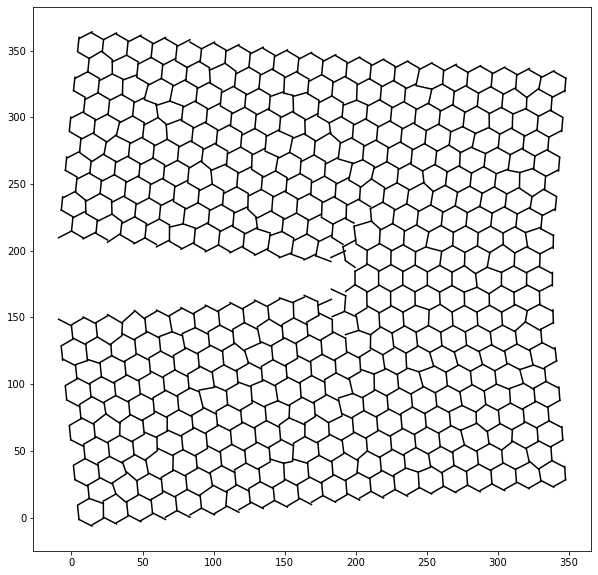

In [95]:
plt.figure(figsize=(10, 10))
for elem in elems:
    n1 = elem[0]
    n2 = elem[1]
    plt.plot([nodes[n1][0]+disps[n1][0], nodes[n2][0]+disps[n2][0]], [nodes[n1][1]+disps[n1][1], nodes[n2][1]+disps[n1][1]], 'k')

Found 0 physical triangles (3-cliques).
Attempting to find 6-cycles...
Trying nx.cycle_basis(G)...
Found 138 6-cycles from cycle_basis.
Found 138 unique 6-cycles to triangulate.
Total unique triangles for strain calculation: 552
Calculated strains for 552 triangles.
Strain range: min=0.0000, max=0.6945


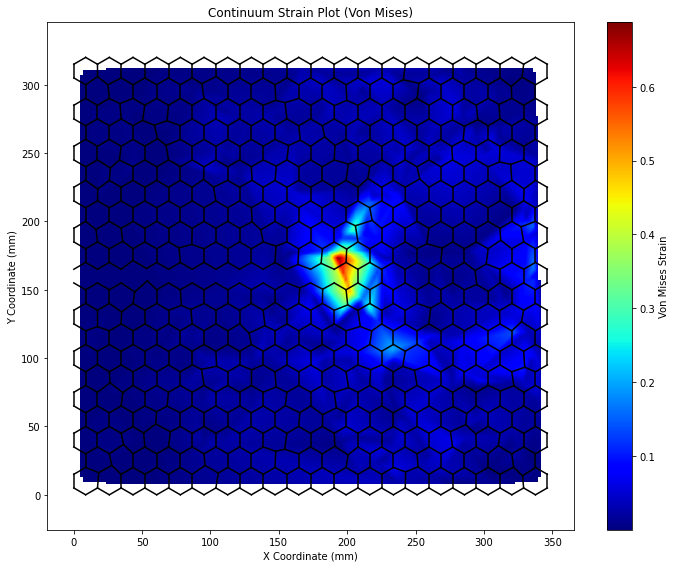

In [ ]:
def calculate_green_lagrange_strain(initial_triangle_coords, final_triangle_coords, strain_type='max_principal'):
    P1 = initial_triangle_coords[0, :]
    P2 = initial_triangle_coords[1, :]
    P3 = initial_triangle_coords[2, :]
    p1 = final_triangle_coords[0, :]
    p2 = final_triangle_coords[1, :]
    p3 = final_triangle_coords[2, :]
    dX = np.array([P2 - P1, P3 - P1]).T
    dx = np.array([p2 - p1, p3 - p1]).T

    F = dx @ np.linalg.inv(dX)
    I = np.eye(2)
    E_tensor = 0.5 * (F.T @ F - I)
    E_xx = E_tensor[0, 0]
    E_yy = E_tensor[1, 1]
    E_xy = E_tensor[0, 1]

    if strain_type == 'max_principal':
        eigenvalues = np.linalg.eigvalsh(E_tensor)
        return np.max(eigenvalues)
    elif strain_type == 'min_principal':
        eigenvalues = np.linalg.eigvalsh(E_tensor)
        return np.min(eigenvalues)
    elif strain_type == 'von_mises':
        e1, e2 = np.linalg.eigvalsh(E_tensor)
        return np.sqrt(e1**2 + e2**2 - e1*e2)
    elif strain_type == 'E_xx':
        return E_xx
    elif strain_type == 'E_yy':
        return E_yy
    elif strain_type == 'E_xy':
        return E_xy

def triangulate_polygon(polygon_nodes):
    triangles = []
    if len(polygon_nodes) < 3:
        return triangles
    p_nodes = list(polygon_nodes)
    root_node = p_nodes[0]
    for i in range(1, len(p_nodes) - 1):
        triangles.append(tuple(sorted((root_node, p_nodes[i], p_nodes[i+1]))))
    return triangles


initial_coords = np.asarray(nodes)
displacements = np.asarray(disps) 
edge_node_pairs = np.asarray(elems) 

final_coords = initial_coords + displacements
num_total_nodes = initial_coords.shape[0]

# --- Element Definition for Strain Calculation ---
G = nx.Graph()
if edge_node_pairs.shape[0] > 0:
    G.add_edges_from(edge_node_pairs)
else:
    print("Warning: No edges provided to build graph.")

all_triangles_for_strain_set = set()

# 1. Find physical triangles (3-cycles/cliques)
if G.number_of_nodes() > 0:
    for clique in nx.find_cliques(G): # find_cliques works for undirected
        if len(clique) == 3:
            all_triangles_for_strain_set.add(tuple(sorted(clique)))
print(f"Found {len(all_triangles_for_strain_set)} physical triangles (3-cliques).")

# 2. Find hexagonal cycles (6-cycles) and triangulate them
hexagonal_cycles_list = []
processed_hex_cycles_normalized = set() # To store unique sets of nodes forming a hexagon

if G.number_of_nodes() > 0:
    print("Attempting to find 6-cycles...")
    cycles_found = []
    try:
        # First, try cycle_basis - often good for faces in planar graphs
        print("Trying nx.cycle_basis(G)...")
        basis_cycles = nx.cycle_basis(G)
        for cycle in basis_cycles:
            if len(cycle) == 6:
                cycles_found.append(list(cycle)) # Keep original order for fan
        print(f"Found {len(cycles_found)} 6-cycles from cycle_basis.")

        # If cycle_basis didn't find many, or if we suspect it's not enough,
        # try simple_cycles with error handling for older versions.
        # This part is more of a fallback or for newer NetworkX.
        if not cycles_found: # Or if you want to augment with simple_cycles anyway
            print("cycle_basis found no 6-cycles (or you want to augment). Trying simple_cycles...")
            cycles_iterator = None
            try:
                # Attempt with length_bound (for NetworkX >= 2.6)
                cycles_iterator = nx.simple_cycles(G, length_bound=6)
            except TypeError as e_lb:
                if "length_bound" in str(e_lb).lower():
                    print("Warning: 'length_bound' not supported. Trying simple_cycles without it.")
                    try:
                        cycles_iterator = nx.simple_cycles(G)
                    except nx.NetworkXNotImplemented:
                        print("nx.simple_cycles not implemented for undirected graphs in this NetworkX version.")
                    except Exception as e_simple_fallback:
                        print(f"Error during fallback nx.simple_cycles: {e_simple_fallback}")
                else:
                    print(f"Unexpected TypeError with simple_cycles: {e_lb}")
            except nx.NetworkXNotImplemented:
                 print("nx.simple_cycles not implemented for undirected graphs in this NetworkX version.")
            except Exception as e_general_simple:
                print(f"General error with simple_cycles: {e_general_simple}")

            if cycles_iterator:
                for cycle in cycles_iterator:
                    # Ensure it's exactly length 6 if length_bound wasn't effective or used
                    if len(cycle) == 6:
                        cycles_found.append(list(cycle))
    except Exception as e_cycle_finding:
        print(f"An error occurred during cycle finding: {e_cycle_finding}")


    # Process all found cycles (from basis or simple_cycles)
    for cycle_nodes_ordered in cycles_found:
        if len(cycle_nodes_ordered) == 6: # Double check length
            normalized_hex_key = tuple(sorted(cycle_nodes_ordered))
            if normalized_hex_key not in processed_hex_cycles_normalized:
                processed_hex_cycles_normalized.add(normalized_hex_key)
                hexagonal_cycles_list.append(list(cycle_nodes_ordered))


print(f"Found {len(hexagonal_cycles_list)} unique 6-cycles to triangulate.")

for hex_cycle_nodes_ordered in hexagonal_cycles_list:
    virtual_tris = triangulate_polygon(hex_cycle_nodes_ordered)
    for tri_tuple in virtual_tris:
        all_triangles_for_strain_set.add(tri_tuple)

triangles_node_indices = np.array(list(all_triangles_for_strain_set), dtype=int)

if triangles_node_indices.shape[0] == 0:
    print("CRITICAL WARNING: No triangles (physical or virtual) were defined for strain calculation.")
else:
    print(f"Total unique triangles for strain calculation: {triangles_node_indices.shape[0]}")

# --- Strain Calculation ---
element_strains = []
element_centroids_initial = []
strain_measure_to_plot = 'von_mises' # Or your preferred measure

if triangles_node_indices.shape[0] > 0:
    for i, tri_indices in enumerate(triangles_node_indices):
        if len(tri_indices) != 3: continue
        initial_triangle_nodes = initial_coords[tri_indices]
        final_triangle_nodes = final_coords[tri_indices]
        strain = calculate_green_lagrange_strain(initial_triangle_nodes, final_triangle_nodes, strain_type=strain_measure_to_plot)
        if not np.isnan(strain):
            element_strains.append(strain)
            element_centroids_initial.append(np.mean(initial_triangle_nodes, axis=0))
else:
    print("Skipping strain calculation as no triangles are defined.")

element_strains = np.array(element_strains)
element_centroids_initial = np.array(element_centroids_initial)

if element_strains.size == 0:
    print("Warning: No valid strains calculated. Plot will be empty or show errors.")

# --- Plotting (imshow) ---
print(f"Calculated strains for {len(element_strains)} triangles.")
if element_strains.size > 0:
    print(f"Strain range: min={np.nanmin(element_strains):.4f}, max={np.nanmax(element_strains):.4f}")
else:
    print("Strain range: N/A (no strains calculated)")


pad_factor = 0.05
if initial_coords.shape[0] > 0:
    x_min_overall, y_min_overall = np.min(initial_coords, axis=0)
    x_max_overall, y_max_overall = np.max(initial_coords, axis=0)
else:
    x_min_overall, y_min_overall = -1, -1
    x_max_overall, y_max_overall = 1, 1

x_range = x_max_overall - x_min_overall
y_range = y_max_overall - y_min_overall
if x_range <= 0: x_range = 1.0
if y_range <= 0: y_range = 1.0

grid_x_coords = np.linspace(x_min_overall - pad_factor * x_range, x_max_overall + pad_factor * x_range, 200)
grid_y_coords = np.linspace(y_min_overall - pad_factor * y_range, y_max_overall + pad_factor * y_range, 200)
GX, GY = np.meshgrid(grid_x_coords, grid_y_coords)

strain_grid = np.full(GX.shape, np.nan)

if element_centroids_initial.shape[0] > 0 and element_strains.shape[0] > 0:
    strain_grid_temp = griddata(element_centroids_initial, element_strains, (GX, GY), method='linear')
    if strain_grid_temp is not None:
        strain_grid = strain_grid_temp

    if element_centroids_initial.shape[0] >=3:
        try:
            tri_centroids = Delaunay(element_centroids_initial)
            grid_points_flat = np.vstack((GX.ravel(), GY.ravel())).T
            simplex_indices = tri_centroids.find_simplex(grid_points_flat)
            mask = simplex_indices != -1
            mask = mask.reshape(GX.shape)
            strain_grid[~mask] = np.nan
        except Exception as e:
            print(f"Warning: Could not perform Delaunay masking: {e}")
    else:
        print("Warning: Not enough centroids for Delaunay masking.")
else:
    print("Skipping griddata and masking as there are no element centroids/strains.")


fig, ax = plt.subplots(figsize=(10, 8))

s_min = np.nanmin(strain_grid if np.any(~np.isnan(strain_grid)) else element_strains)
s_max = np.nanmax(strain_grid if np.any(~np.isnan(strain_grid)) else element_strains)

cmap_imshow = plt.get_cmap('jet')
im = ax.imshow(strain_grid, extent=(grid_x_coords[0], grid_x_coords[-1], grid_y_coords[0], grid_y_coords[-1]),
               origin='lower', cmap=cmap_imshow, aspect='auto',
               vmin=s_min, vmax=s_max, interpolation='bilinear')

if edge_node_pairs.shape[0] > 0 and initial_coords.shape[0] > 0:
    for n1_idx, n2_idx in edge_node_pairs:
        ax.plot([initial_coords[n1_idx,0], initial_coords[n2_idx,0]],
                [initial_coords[n1_idx,1], initial_coords[n2_idx,1]],
                'k')


plt.colorbar(im, label=f'{strain_measure_to_plot.replace("_", " ").title()} Strain')
plt.title(f'Continuum Strain Plot ({strain_measure_to_plot.replace("_", " ").title()})')
plt.xlabel('X Coordinate (mm)')
plt.ylabel('Y Coordinate (mm)')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [96]:
def calculate_green_lagrange_strain(initial_triangle_coords, final_triangle_coords, strain_type='max_principal'):
    P1 = initial_triangle_coords[0, :]
    P2 = initial_triangle_coords[1, :]
    P3 = initial_triangle_coords[2, :]
    p1 = final_triangle_coords[0, :]
    p2 = final_triangle_coords[1, :]
    p3 = final_triangle_coords[2, :]
    dX = np.array([P2 - P1, P3 - P1]).T
    dx = np.array([p2 - p1, p3 - p1]).T

    F = dx @ np.linalg.inv(dX)
    I = np.eye(2)
    E_tensor = 0.5 * (F.T @ F - I)
    E_xx = E_tensor[0, 0]
    E_yy = E_tensor[1, 1]
    E_xy = E_tensor[0, 1]

    if strain_type == 'max_principal':
        eigenvalues = np.linalg.eigvalsh(E_tensor)
        return np.max(eigenvalues)
    elif strain_type == 'min_principal':
        eigenvalues = np.linalg.eigvalsh(E_tensor)
        return np.min(eigenvalues)
    elif strain_type == 'von_mises':
        e1, e2 = np.linalg.eigvalsh(E_tensor)
        return np.sqrt(e1**2 + e2**2 - e1*e2)
    elif strain_type == 'E_xx':
        return E_xx
    elif strain_type == 'E_yy':
        return E_yy
    elif strain_type == 'E_xy':
        return E_xy

def find_triangles_from_edges(edge_list_node_pairs, num_total_nodes):
    adj = [set() for _ in range(num_total_nodes)]
    for n1, n2 in edge_list_node_pairs:
        adj[n1].add(n2)
        adj[n2].add(n1)

    found_triangles_set = set()
    for u in range(num_total_nodes):
        if not adj[u]:
            continue
        neighbors_of_u = list(adj[u])
        for i in range(len(neighbors_of_u)):
            v = neighbors_of_u[i]
            if v <= u: 
                continue
            for w in adj[v]:
                if w <= v: 
                    continue
                if w in adj[u]:
                    triangle_nodes = tuple(sorted((u, v, w)))
                    found_triangles_set.add(triangle_nodes)
        
    return np.array(list(found_triangles_set), dtype=int)

initial_coords = nodes
displacements = disps
edge_node_pairs = elems

initial_coords = np.asarray(initial_coords)
displacements = np.asarray(displacements)
final_coords = initial_coords + displacements

num_total_nodes = initial_coords.shape[0]

triangles_node_indices = find_triangles_from_edges(edge_node_pairs, num_total_nodes)

print(f"Found {triangles_node_indices.shape[0]} triangles from edge connectivity.")

element_strains = []
element_centroids_initial = []

strain_measure_to_plot = 'von_mises'

for i, tri_indices in enumerate(triangles_node_indices):
    initial_triangle_nodes = initial_coords[tri_indices]
    final_triangle_nodes = final_coords[tri_indices]

    strain = calculate_green_lagrange_strain(initial_triangle_nodes, final_triangle_nodes, strain_type=strain_measure_to_plot)
    
    element_strains.append(strain)
    centroid = np.mean(initial_triangle_nodes, axis=0)
    element_centroids_initial.append(centroid)

element_strains = np.array(element_strains)
element_centroids_initial = np.array(element_centroids_initial)

# fig1 = plt.figure(figsize=(10, 6))
# ax = fig1.add_subplot()
# ax.set_xlabel('x')
# ax.set_ylabel('y')
# ctr = ax.tricontourf(element_centroids_initial[:,0], element_centroids_initial[:,1], element_strains, cmap="jet")
# plt.colorbar(ctr)

print(f"Calculated strains for {len(element_strains)} triangles.")
print(f"Strain range: min={np.min(element_strains):.4f}, max={np.max(element_strains):.4f}")

pad_factor = 0.05
x_min_overall, y_min_overall = np.min(initial_coords, axis=0)
x_max_overall, y_max_overall = np.max(initial_coords, axis=0)
x_range = x_max_overall - x_min_overall
y_range = y_max_overall - y_min_overall

grid_x_coords = np.linspace(x_min_overall - pad_factor * x_range, x_max_overall + pad_factor * x_range, 200)
grid_y_coords = np.linspace(y_min_overall - pad_factor * y_range, y_max_overall + pad_factor * y_range, 200)
GX, GY = np.meshgrid(grid_x_coords, grid_y_coords)

strain_grid = griddata(element_centroids_initial, element_strains, (GX, GY), method='linear')

tri_centroids = Delaunay(element_centroids_initial)
grid_points_flat = np.vstack((GX.ravel(), GY.ravel())).T
simplex_indices = tri_centroids.find_simplex(grid_points_flat)

mask = simplex_indices != -1
mask = mask.reshape(GX.shape)

strain_grid[~mask] = np.nan

fig, ax = plt.subplots(figsize=(10, 8))

s_min = np.nanmin(strain_grid if np.any(~np.isnan(strain_grid)) else element_strains)
s_max = np.nanmax(strain_grid if np.any(~np.isnan(strain_grid)) else element_strains)

cmap_imshow = plt.get_cmap('jet')
cmap_imshow.set_bad(color='white', alpha=1) 
im = ax.imshow(strain_grid, extent=(grid_x_coords[0], grid_x_coords[-1], grid_y_coords[0], grid_y_coords[-1]),
               origin='lower', cmap=cmap_imshow, aspect='auto',
               vmin=s_min, vmax=s_max, interpolation='bilinear')
for i in elems:
    n1 = i[0]
    n2 = i[1]
    ax.plot([initial_coords[n1][0], initial_coords[n2][0]], [initial_coords[n1][1], initial_coords[n2][1]], 'k')

plt.colorbar(im, label=f'{strain_measure_to_plot.replace("_", " ").title()} Strain')
plt.title(f'Continuum Strain Plot ({strain_measure_to_plot.replace("_", " ").title()})')
plt.xlabel('X Coordinate (mm)')
plt.ylabel('Y Coordinate (mm)')
plt.axis('equal')
plt.tight_layout()
plt.show()

Found 0 triangles from edge connectivity.
Calculated strains for 0 triangles.


ValueError: zero-size array to reduction operation minimum which has no identity